# Notebook per i plot

## Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
from scipy.optimize import least_squares
from scipy.special import spherical_jn as jn
import emcee
import os
from multiprocessing import Pool
import corner

import utils.lib.nn_studio as nn_studio
import utils.lib.chiral_potential as chiral_potential
import utils.lib.granada_phases as granada
import utils.lib.auxiliary as aux
import utils.lib.lec_values as lec_values
from utils.lib.constants import *

import time
import datetime

In [ ]:
%matplotlib widget
plt.close("all")

## Caricamento dati

In [ ]:
LO_chain = np.load("results/bayes_samples_LO.npy")
NLO_chain = np.load("results/bayes_samples_NLO.npy")

In [ ]:
param_names_LO = [r"C_{1S0}", r"C_{3S1}"]
param_names_NLO = [r"$C_{1S0}$", r"$C_{3S1}$", r"$D_{1S0}$", r"$D_{3S1}$", r"$D_{mix}$"]

## Corner plot

In [ ]:
fig = plt.figure(figsize=(8, 8))


corner.corner(
    LO_chain, 
    labels=[r"$C_{1S0}$", r"$C_{3S1}$"], 
    show_titles=False,
    fig=fig, 
    color="green", 
    verbose=False,
    use_math_text=True,
    quantiles=[0.16, 0.5, 0.84],
    label_kwargs={"fontsize": 12}
)

fig.suptitle("Corner Plot - LO", fontsize=16)
fig.tight_layout()

fig.savefig("figure/corner_LO.pdf", bbox_inches="tight")

plt.show()

In [ ]:
fig = plt.figure(figsize=(15, 15))


corner.corner(
    NLO_chain[int(0.5*len(NLO_chain)):], 
    labels=[r"$C_{1S0}$", r"$C_{3S1}$", r"$C_{1P1}$", r"$C_{3P0}$", r"$C_{3P1}$", r"$C_{3P2}$"], 
    show_titles=False,
    fig=fig, 
    color="blue", 
    verbose=False,
    use_math_text=True,
    quantiles=[0.16, 0.5, 0.84],
    label_kwargs={"fontsize": 18}
)

fig.suptitle("Corner Plot - NLO", fontsize=20)
fig.tight_layout()

fig.savefig("figure/corner_NLO.pdf", bbox_inches="tight")

plt.show()

## Trace dei parametri

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5))

param1 = LO_chain[:, 0]
param2 = LO_chain[:, 1]

axes[0].plot(param1, color="green", alpha=0.5)
axes[0].set_title(r"$C_{1S0}$ - LO", fontsize=14)
axes[0].set_xlabel("Step", fontsize=12)
axes[0].set_ylabel("Value", fontsize=12)
axes[1].plot(param2, color="green", alpha=0.5)
axes[1].set_title(r"$C_{3S1}$ - LO", fontsize=14)
axes[1].set_xlabel("Step", fontsize=12)
axes[1].set_ylabel("Value", fontsize=12)
fig.tight_layout()
fig.savefig("figure/trace_LO.pdf", bbox_inches="tight")
plt.show()

In [ ]:
fig, axes = plt.subplots(NLO_chain.shape[1], 1, figsize=(12, 20))

params = [NLO_chain[:, i] for i in range(NLO_chain.shape[1])]
param_names = param_names_NLO

for p, n in zip(params, param_names):
    idx = param_names.index(n)
    axes[idx].plot(p, color="blue", alpha=0.5)
    axes[idx].set_title(f"{n} - NLO", fontsize=14)
    axes[idx].set_xlabel("Step", fontsize=12)
    axes[idx].set_ylabel("Value", fontsize=12)
fig.tight_layout()
fig.savefig("figure/trace_NLO.pdf", bbox_inches="tight")
plt.show()

## Confronto modello-dati

### Calcolo dei best fit ed errori sui parametri

In [ ]:
best_params_LO = np.median(LO_chain, axis=0)
errors_LO = np.percentile(LO_chain, [16, 84], axis=0) - best_params_LO


best_params_NLO = np.median(NLO_chain[int(0.5*len(NLO_chain)):], axis=0)
errors_NLO = np.percentile(NLO_chain[int(0.5*len(NLO_chain)):], [16, 84], axis=0) - best_params_NLO

### Inizializzazione nn_studio e import dei dati

In [ ]:
# Caricamento dati Granada

T_Lab = granada.Tlabs

shift_1S0 = granada.delta_1S0
shift_1S0_error = granada.delta_1S0_errors

shift_3S1 = granada.delta_3S1
shift_3S1_error = granada.delta_3S1_errors

shift_3D1 = granada.delta_3D1
shift_3D1_error = granada.delta_3D1_errors

shift_mix = granada.delta_3E1
shift_mix_error = granada.delta_3E1_errors

experimental_shifts = {
    "shift_1S0": (shift_1S0, shift_1S0_error),
    "shift_3S1": (shift_3S1, shift_3S1_error),
    "shift_3D1": (shift_3D1, shift_3D1_error),
    "shift_mix": (shift_mix, shift_mix_error)
}


In [ ]:
# Inizializzazione nn_studio

nn = nn_studio.nn_studio(jmin=0, jmax=1, tzmin=0, tzmax=0, Np=30, mesh_type="gauleg_infinite")
nn.Tlabs = T_Lab

### Lookup dei canali e calcolo phase shifts

In [ ]:
# lookup dei canali di interesse

_, channel_1S0 = nn.lookup_channel_idx(l=0,ll=0,s=0,j=0) # Il canale 1S0 è il primo orbitale anti-legante, in cui gli spin sono accoppiati (chn_idx=0)
_, channel_3S1 = nn.lookup_channel_idx(l=0,ll=2,s=1,j=1) # Il canale 3S1 è quello del ground state del deutone, in cui si accoppiano 3S1-3D1 (chn_idx=4)
_, channel_3D1 = nn.lookup_channel_idx(l=2,ll=0,s=1,j=1) # Il canale 3D1 è quello del ground state del deutone, in cui si accoppiano 3S1-3D1 (chn_idx=5)
_, channel_mix = nn.lookup_channel_idx(l=0,ll=2,s=1,j=1) # Il canale di miscela 3S1-3D1 è quello del ground state del deutone, in cui si accoppiano 3S1-3D1 (chn_idx=4)


In [ ]:
for i in channel_3S1[0]:
    print(i)

In [ ]:
def compute_phase_shifts(lecs, channel, model="LO", E_lambda=500.0):

    if model == "LO":
        lecs = {
            "C_1S0": lecs[0],
            "C_3S1": lecs[1]
        }

    elif model == "NLO":
        lecs = {
            "C_1S0" : lecs[0],
            "C_3S1" : lecs[1],
            "D_1S0" : lecs[2],
            "D_3S1" : lecs[3],
            "D_mix" : lecs[4]
        }

    else:
        raise NotImplementedError("Modello non implementato")
    
    nn = nn_studio.nn_studio(jmin=0, jmax=1, tzmin=0, tzmax=0, Np=30, mesh_type="gauleg_infinite")
    nn.Tlabs = T_Lab

    nn.V = chiral_potential.two_nucleon_potential(model, Lambda=E_lambda)
    nn.lecs = lecs
    nn.compute_Tmtx(channel, verbose=False)

    return nn.phase_shifts


### Confronto LO vs dati

In [78]:
# Creazione figure per confronto LO vs dati
with plt.ioff():

    fig_LO_1S0, ax_LO_1S0 = plt.subplots(1, 1)
    fig_LO_1S0_residuals, ax_LO_1S0_residuals = plt.subplots(1, 1)

    fig_LO_3S1, ax_LO_3S1 = plt.subplots(1, 1)
    fig_LO_3S1_residuals, ax_LO_3S1_residuals = plt.subplots(1, 1)

    # Titoli e etichette assi
    ax_LO_1S0.set_title("LO - Canale 1S0", fontsize=14)
    ax_LO_1S0.set_xlabel(r"$T_{Lab}$ [MeV]", fontsize=12)
    ax_LO_1S0.set_ylabel(r"Phase Shift [deg]", fontsize=12)

    ax_LO_3S1.set_title("LO - Canale 3S1", fontsize=14)
    ax_LO_3S1.set_xlabel(r"$T_{Lab}$ [MeV]", fontsize=12)
    ax_LO_3S1.set_ylabel(r"Phase Shift [deg]", fontsize=12)

    ax_LO_1S0_residuals.set_title("LO - Residui 1S0", fontsize=14)
    ax_LO_1S0_residuals.set_xlabel(r"$T_{Lab}$ [MeV]", fontsize=12)
    ax_LO_1S0_residuals.set_ylabel(r"Residuals [deg]", fontsize=12)

    ax_LO_3S1_residuals.set_title("LO - Residui 3S1", fontsize=14)
    ax_LO_3S1_residuals.set_xlabel(r"$T_{Lab}$ [MeV]", fontsize=12)
    ax_LO_3S1_residuals.set_ylabel(r"Residuals [deg]", fontsize=12)

    # calcolo dei phase shifts e residui per LO
    phase_shifts_LO_1S0 = compute_phase_shifts(best_params_LO, channel_1S0, model="LO")[0]
    phase_shifts_LO_1S0_max = compute_phase_shifts(best_params_LO + errors_LO[1], channel_1S0, model="LO")[0]
    phase_shifts_LO_1S0_min = compute_phase_shifts(best_params_LO + errors_LO[0], channel_1S0, model="LO")[0]
    residuals_LO_1S0 = phase_shifts_LO_1S0 - experimental_shifts["shift_1S0"][0]
    phase_shifts_LO_3S1 = compute_phase_shifts(best_params_LO, channel_3S1, model="LO")[0][:,0]
    phase_shifts_LO_3S1_max = compute_phase_shifts(best_params_LO + errors_LO[1], channel_3S1, model="LO")[0][:,0]
    phase_shifts_LO_3S1_min = compute_phase_shifts(best_params_LO + errors_LO[0], channel_3S1, model="LO")[0][:,0]
    residuals_LO_3S1 = phase_shifts_LO_3S1 - experimental_shifts["shift_3S1"][0]

    # plot dei phase shifts e residui per LO
    ax_LO_1S0.errorbar(T_Lab, experimental_shifts["shift_1S0"][0], yerr=experimental_shifts["shift_1S0"][1], fmt="o", label="Dati Granada - 1S0", color="black", markersize=5)
    ax_LO_1S0.plot(T_Lab, phase_shifts_LO_1S0, label="Modello - LO", color="green", marker="o", markersize=5)
    ax_LO_1S0.fill_between(T_Lab, phase_shifts_LO_1S0_min, phase_shifts_LO_1S0_max, color="green", alpha=0.3, label="Uncertainty - LO")

    ax_LO_1S0_residuals.plot(T_Lab, residuals_LO_1S0, label="Residui - LO", color="red", marker="o", markersize=5)
    ax_LO_1S0_residuals.axhline(0, color="gray", linestyle="--", alpha=0.7)

    ax_LO_3S1.errorbar(T_Lab, experimental_shifts["shift_3S1"][0], yerr=experimental_shifts["shift_3S1"][1], fmt="o", label="Dati Granada - 3S1", color="black", markersize=5)
    ax_LO_3S1.plot(T_Lab, phase_shifts_LO_3S1, label="Modello - LO", color="green", marker="o", markersize=5)
    ax_LO_3S1.fill_between(T_Lab, phase_shifts_LO_3S1_min, phase_shifts_LO_3S1_max, color="green", alpha=0.3, label="Uncertainty - LO")

    ax_LO_3S1_residuals.plot(T_Lab, residuals_LO_3S1, label="Residui - LO", color="red", marker="o", markersize=5)
    ax_LO_3S1_residuals.axhline(0, color="gray", linestyle="--", alpha=0.7)

    LO_figs = [fig_LO_1S0, fig_LO_3S1, fig_LO_1S0_residuals, fig_LO_3S1_residuals]

    # tight layout su tutto
    [fig.tight_layout() for fig in LO_figs]

    # salvataggio figure
    fig_names = ["LO_1S0", "LO_3S1", "LO_1S0_residuals", "LO_3S1_residuals"]
    [fig.savefig(f"figure/{name}.pdf", bbox_inches="tight") for fig, name in zip(LO_figs, fig_names)]





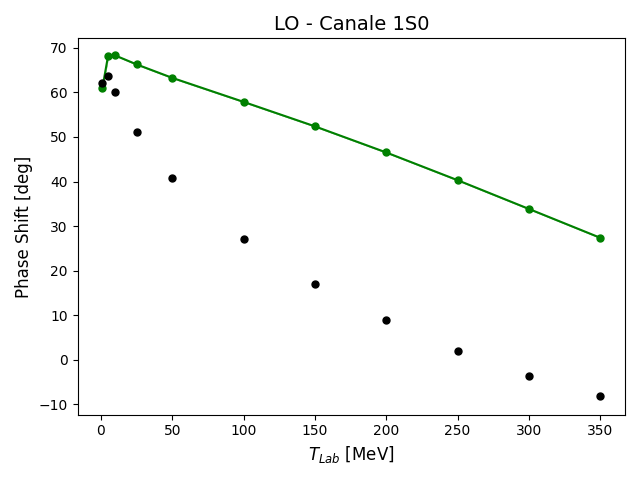

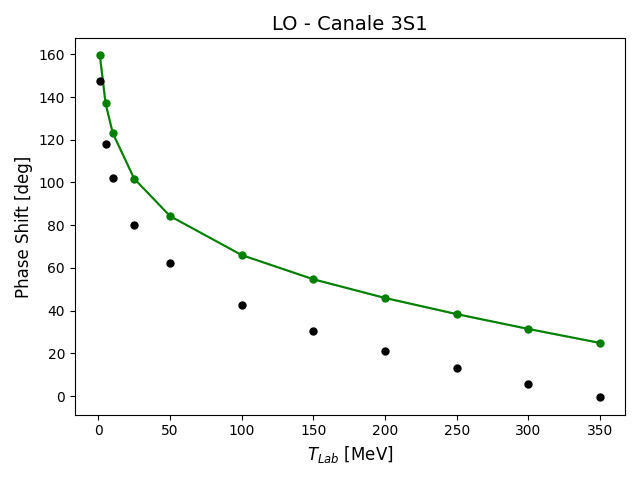

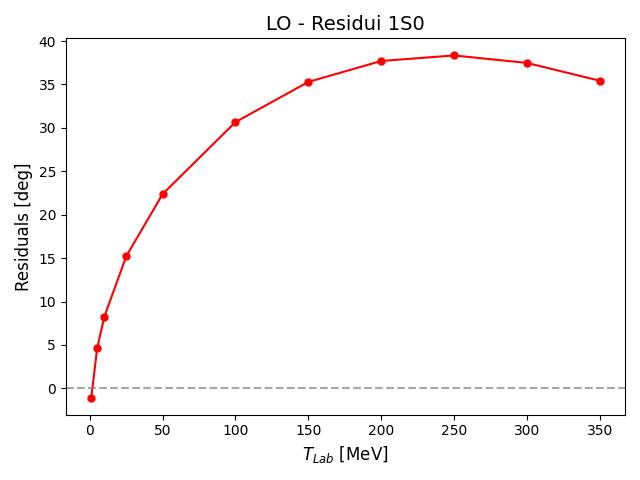

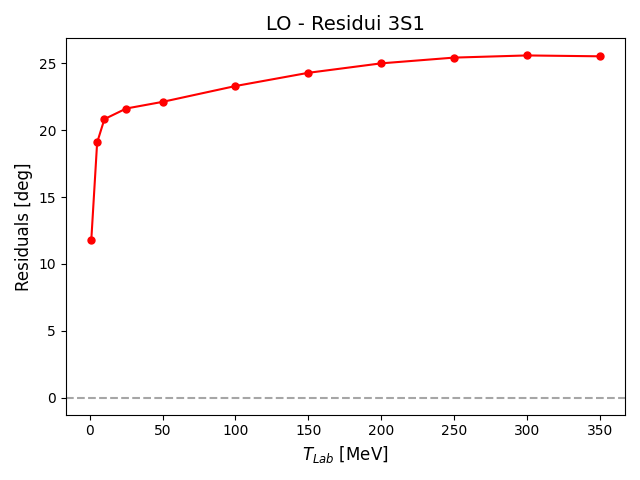

[None, None, None, None]

In [79]:
[fig.show() for fig in LO_figs]